#ML FINAL

### Name: Sadat Maliha Mashiat

### Email: sadatmaliha703@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions: https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans


In [3]:
df = pd.read_csv("cancer.csv")

## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

#Answer:

I found this dataset interesting as Breast Cancer is a global issue now. Also it is suitable for learning and applying machine learning classification techniques.

The dataset is relatively small and contains no missing values, making it suitable for practicing data preprocessing and exploratory data analysis. The main challenge is handling categorical features correctly and considering class imbalance when building a classification model.





# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

###Answer:

In [ ]:
display(df.shape)

display(df.sample(5))

display(df.isnull().sum())

display(df.duplicated().sum())

df.info()

df.describe()

(683, 10)

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
177,1,5,8,8,8,5,10,7,8,1
572,0,5,1,1,1,2,1,2,2,1
597,1,8,10,10,10,6,10,10,10,10
146,0,1,1,1,1,1,1,3,1,1
212,1,6,10,7,7,6,4,8,10,2


,0
Class,0
age,0
menopause,0
tumor-size,0
inv-nodes,0
node-caps,0
deg-malig,0
breast,0
breast-quad,0
irradiat,0


np.int64(234)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Class        683 non-null    int64
 1   age          683 non-null    int64
 2   menopause    683 non-null    int64
 3   tumor-size   683 non-null    int64
 4   inv-nodes    683 non-null    int64
 5   node-caps    683 non-null    int64
 6   deg-malig    683 non-null    int64
 7   breast       683 non-null    int64
 8   breast-quad  683 non-null    int64
 9   irradiat     683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,0.349927,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221
std,0.477296,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,0.000000,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,1.000000,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


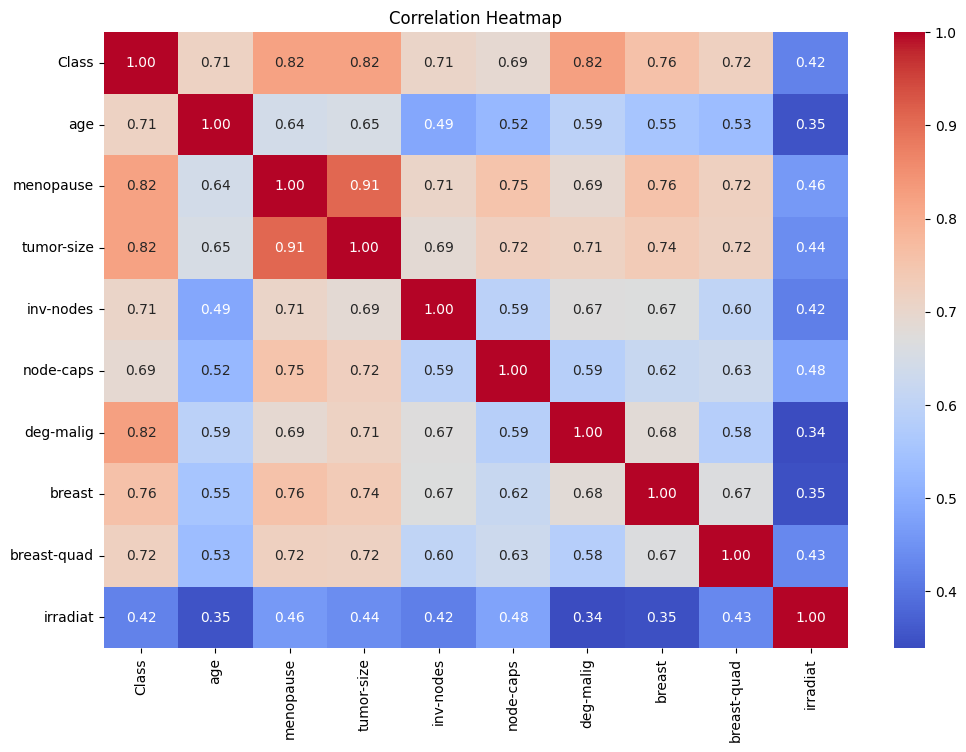

In [ ]:
#Correlation Heatmap
corr = df.corr(numeric_only = True)

plt.figure(figsize = (12, 8))
sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm",
    fmt = "0.2f"
)

plt.title("Correlation Heatmap")
plt.show()

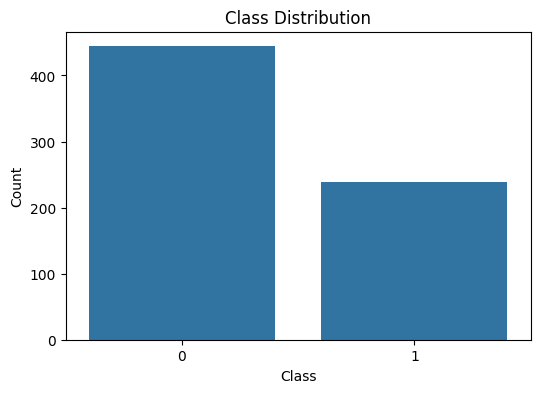

Class
0    444
1    239
Name: count, dtype: int64


In [ ]:
#Class Distribution
plt.figure(figsize = (6, 4))

sns.countplot(data=df, x = "Class")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

print(df["Class"].value_counts())

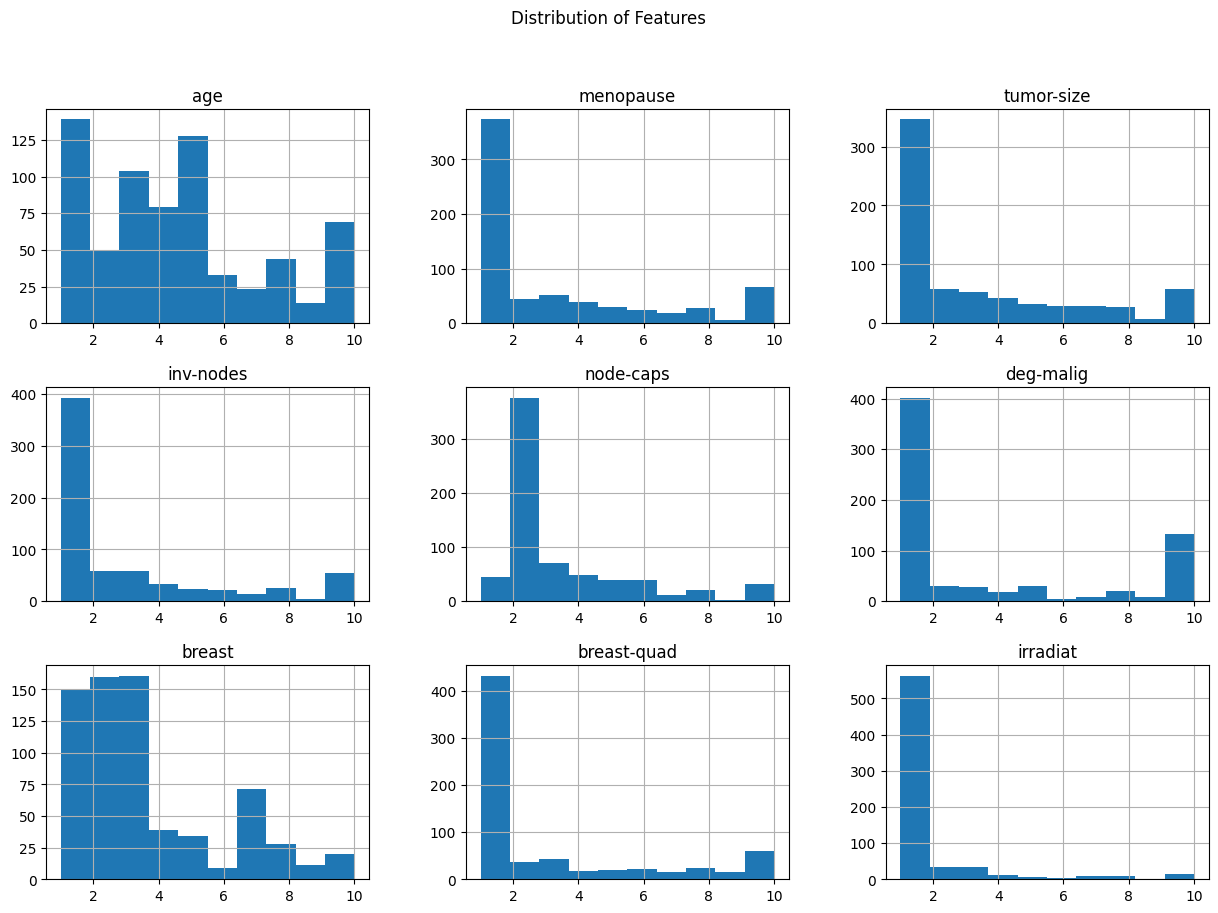

In [ ]:
#Feature Distribution
df.drop("Class", axis = 1).hist(
    figsize = (15, 10),
    bins = 10
)

plt.suptitle("Distribution of Features")
plt.show()

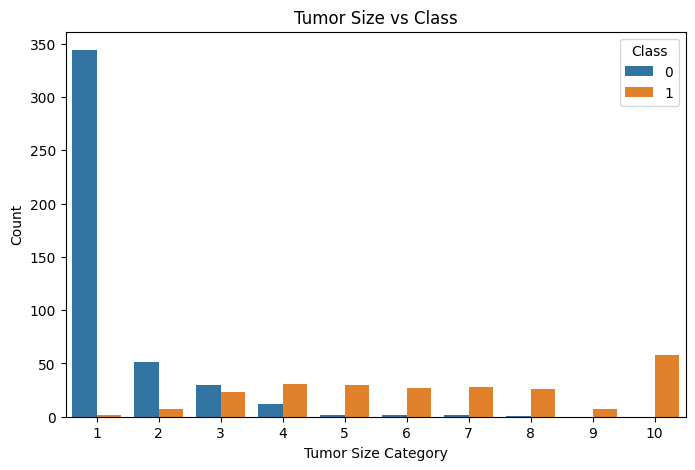

In [ ]:
#Tumor Size vs Class
plt.figure(figsize = (8, 5))

sns.countplot(
    data = df,
    x = "tumor-size",
    hue = "Class"
)

plt.title("Tumor Size vs Class")
plt.xlabel("Tumor Size Category")
plt.ylabel("Count")

plt.show()

1. Features: 9

2. As this dataset's target column has 0 and 1 category so i think this is a binary classification problem.

3. Data points: 683

4. There is no null values in this cancer dataset.

5. The dataset contains ordinal categorical features stored as numerical codes.

6. As machine learning models do not understand categorical values so that we have to encode categorical values to numerical values using Nominal encoding or Ordinal encoding. But in this dataset all categorical values are already encoded using Ordinal encoding so that i do not have to encode them further.

7. deg-malig, tumor-size and menopause has linear association with class.

8. The countplot shows tumor-size has significant effect on class.





#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [4]:
#Check missing value
print("Total missing values:", df.isnull().sum().sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

#Train_Test Split
X = df.drop("Class", axis = 1)
Y = df["Class"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)


#One-hot encoding
categorical_features = X.columns.tolist()

encoder = OneHotEncoder(
    handle_unknown = "ignore",
    sparse_output = False,
    drop = 'first'
)

encoder.set_output(transform = 'pandas')

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

print("Encoded feature shape for X_train:", X_train_encoded.shape)
print("Encoded feature shape for X_test:", X_test_encoded.shape)
print("Target shape:", Y.shape)

Total missing values: 0
Duplicate rows: 234
Shape after removing duplicates: (449, 10)
Encoded feature shape for X_train: (359, 80)
Encoded feature shape for X_test: (90, 80)
Target shape: (449,)


1. As there is no missing value so that imputation is not needed.

2. 234 duplicate rows droped.

3. Applied one-hot encoding to prevent artificial ordering among nominal features.

4. I think scaling is not necessary in this step.

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



In [ ]:
#Train_Test Split
X = df.drop('Class', axis = 1)
Y = df['Class']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("Training target shape:", Y_train.shape)
print("Testing target shape:", Y_test.shape)

Training features shape: (359, 9)
Testing features shape: (90, 9)
Training target shape: (359,)
Testing target shape: (90,)


1. I decided to keep all nine features because the dataset contains only a small number of features, and there is no sufficient evidence that any feature is irrelevant. Removing features based only on correlation may result in information loss. Therefore, no feature was dropped, and no additional feature engineering was performed.

2. The dataset was split into 80% training data and 20% testing data using train_test_split(). I used random_state = 42 to ensure reproducibility and stratify = Y to preserve the class distribution in both subsets. This resulted in 359 training samples and 90 testing samples.

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [12]:
#Train_Test Split
X = df.drop('Class', axis = 1)
Y = df['Class']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

#Categorical Features
categorical_features = X.columns.tolist()

#Preprocessor for Logistic Regression and KNN
logistic_knn_preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown = 'ignore', drop = 'first', sparse_output = False), categorical_features)
    ],
    remainder = "drop"
)

#Pipeline - 01: Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ('preprocessing', logistic_knn_preprocessor),
        ('scaling', StandardScaler()),
        ('model', LogisticRegression(class_weight = 'balanced', max_iter = 1000))
    ]
)

#Pipeline - 02: KNN
knn_pipeline = Pipeline(
    steps=[
        ('preprocessing', logistic_knn_preprocessor),
        ('scaling', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors = 5))
    ]
)

print("Logistic Regression Pipeline:")
display(logistic_pipeline)

print("\nKNN Pipeline:")
display(knn_pipeline)

Logistic Regression Pipeline:


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['age', 'menopause',
                                                   'tumor-size', 'inv-nodes',
                                                   'node-caps', 'deg-malig',
                                                   'breast', 'breast-quad',
                                                   'irradiat'])])),
                ('scaling', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])


KNN Pipeline:


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['age', 'menopause',
                                                   'tumor-size', 'inv-nodes',
                                                   'node-caps', 'deg-malig',
                                                   'breast', 'breast-quad',
                                                   'irradiat'])])),
                ('scaling', StandardScaler()),
                ('model', KNeighborsClassifier())])

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [14]:
#Train Logistic Regression and KNN
logistic_pipeline.fit(X_train, Y_train)
knn_pipeline.fit(X_train, Y_train)

#Predictions
logistic_predictions = logistic_pipeline.predict(X_test)
knn_predictions = knn_pipeline.predict(X_test)

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [17]:
#Calculate metrics
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN'],
    'Accuracy': [
        accuracy_score(Y_test, logistic_predictions),
        accuracy_score(Y_test, knn_predictions)
    ],
    'Precision': [
        precision_score(Y_test, logistic_predictions, zero_division = 0),
        precision_score(Y_test, knn_predictions, zero_division = 0)
    ],
    'Recall': [
        recall_score(Y_test, logistic_predictions, zero_division = 0),
        recall_score(Y_test, knn_predictions, zero_division = 0)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.988889   0.979167  1.000000
1                  KNN  0.733333   1.000000  0.489362


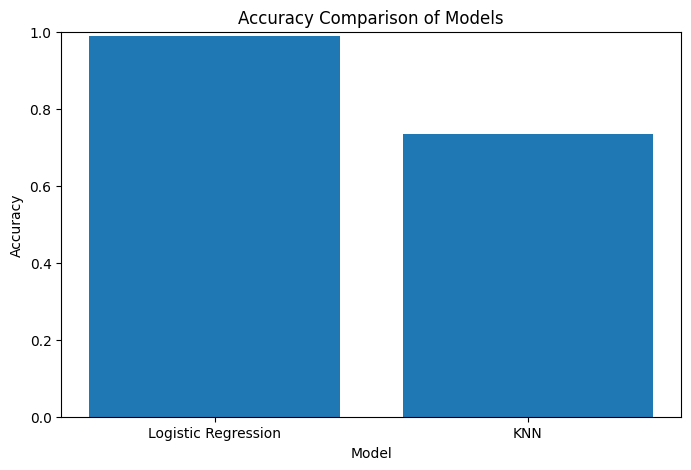

In [18]:
#Accuracy comparison bar chart
plt.figure(figsize = (8, 5))

plt.bar(
    results['Model'],
    results['Accuracy']
)

plt.title('Accuracy Comparison of Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

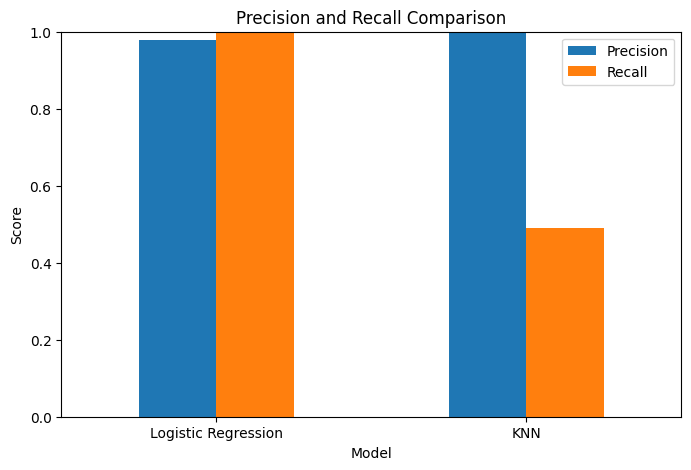

In [19]:
#Precision and recall comparison
results.plot(
    x='Model',
    y = ['Precision', 'Recall'],
    kind = 'bar',
    figsize = (8, 5)
)

plt.title('Precision and Recall Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

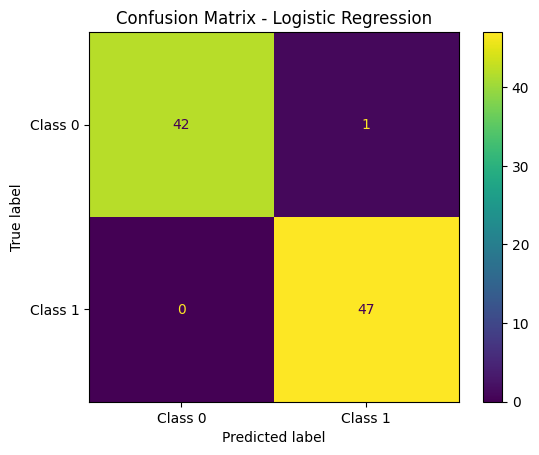

In [20]:
#Confusion Matrix — Logistic Regression
cm_logistic = confusion_matrix(
    Y_test,
    logistic_predictions
)

disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix = cm_logistic,
    display_labels = ['Class 0', 'Class 1']
)

disp_logistic.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

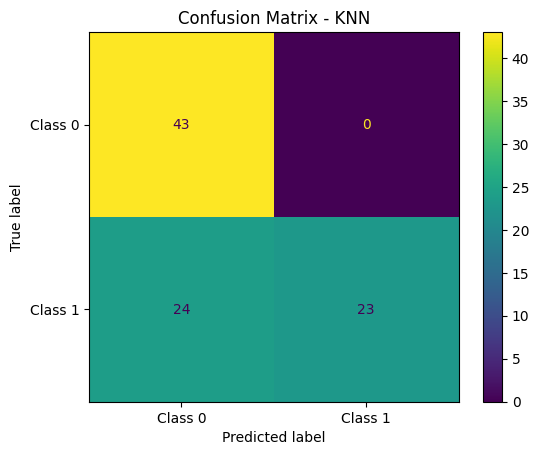

In [21]:
#Confusion Matrix — KNN
cm_knn = confusion_matrix(
    Y_test,
    knn_predictions
)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix = cm_knn,
    display_labels = ['Class 0', 'Class 1']
)

disp_knn.plot()
plt.title('Confusion Matrix - KNN')
plt.show()

Logistic Regression performed better than KNN. It achieved higher accuracy (98.89%) and recall (100%), while KNN achieved only 73.33% accuracy and 48.94% recall. Although KNN had slightly higher precision (100%), Logistic Regression is more suitable for this dataset because it correctly identified all positive cases. This may be because the encoded features have a relatively linear relationship with the target variable.

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

In [6]:
#Feature Selection
X_unsupervised = df.drop('Class', axis = 1)
Y_actual = df['Class']

#One-hot encoding
encoder = OneHotEncoder(
    handle_unknown = 'ignore',
    drop = 'first',
    sparse_output = False
)

X_encoded = encoder.fit_transform(X_unsupervised)

#K-Means model
kmeans = KMeans(
    n_clusters = 2,
    random_state = 42,
    init = 'k-means++',
    max_iter = 400
)

clusters = kmeans.fit_predict(X_encoded)

#Inertia / SSE
inertia = kmeans.inertia_
print("Inertia:", inertia)


Inertia: 2514.67775483247


The supervised approach performed better than the unsupervised approach. Logistic Regression achieved 98.89% accuracy and 100% recall, while K-Means only formed clusters based on feature similarity without using the actual class labels.

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

The hardest topic for me was Gradient Descent. At first, it was difficult to understand how a model reduces its error by updating its parameters step by step. The learning rate and mathematical calculations also made it challenging. I understood it better by imagining a person walking down a hill to reach the lowest point. Similarly, a machine learning model uses Gradient Descent to minimize loss and improve its predictions. It is important because many machine learning models use it to learn from data.

The easiest topic for me was Feature Engineering and Preprocessing. I found it easy because it involves preparing raw data and selecting useful features before training a model. For example, missing values can be handled, categorical data can be encoded, and unnecessary features can be removed. In real-world applications, good preprocessing makes data more suitable for machine learning and can improve model performance.